<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Numerical_Solution_Example_in_QuTiP_versus_Numerov_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [2]:
!python -m pip install -q uv
!uv pip install --system -q "qutip>=5.3" numpy scipy matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 62.9 MB/s eta 0:00:00


,n,Exact E_n,QuTiP FD E_n,Numerov E_n,QuTiP minus exact,Numerov minus exact,QuTiP minus Numerov,L2 psi difference
0,0,0.5,0.499984,0.500000,-0.000016,-1.066599e-09,-0.000016,0.000024
1,1,1.5,1.499918,1.500000,-0.000082,-7.464900e-09,-0.000082,0.000068
2,2,2.5,2.499788,2.500000,-0.000212,-2.665872e-08,-0.000212,0.000136
3,3,3.5,3.499592,3.500000,-0.000408,-6.718243e-08,-0.000408,0.000232
4,4,4.5,4.499331,4.500000,-0.000669,-1.375679e-07,-0.000669,0.000358
5,5,5.5,5.499004,5.500000,-0.000996,-2.463503e-07,-0.000996,0.000514
6,6,6.5,6.498612,6.500000,-0.001388,-4.020656e-07,-0.001388,0.000701
7,7,7.5,7.498155,7.499999,-0.001845,-6.132515e-07,-0.001845,0.000918


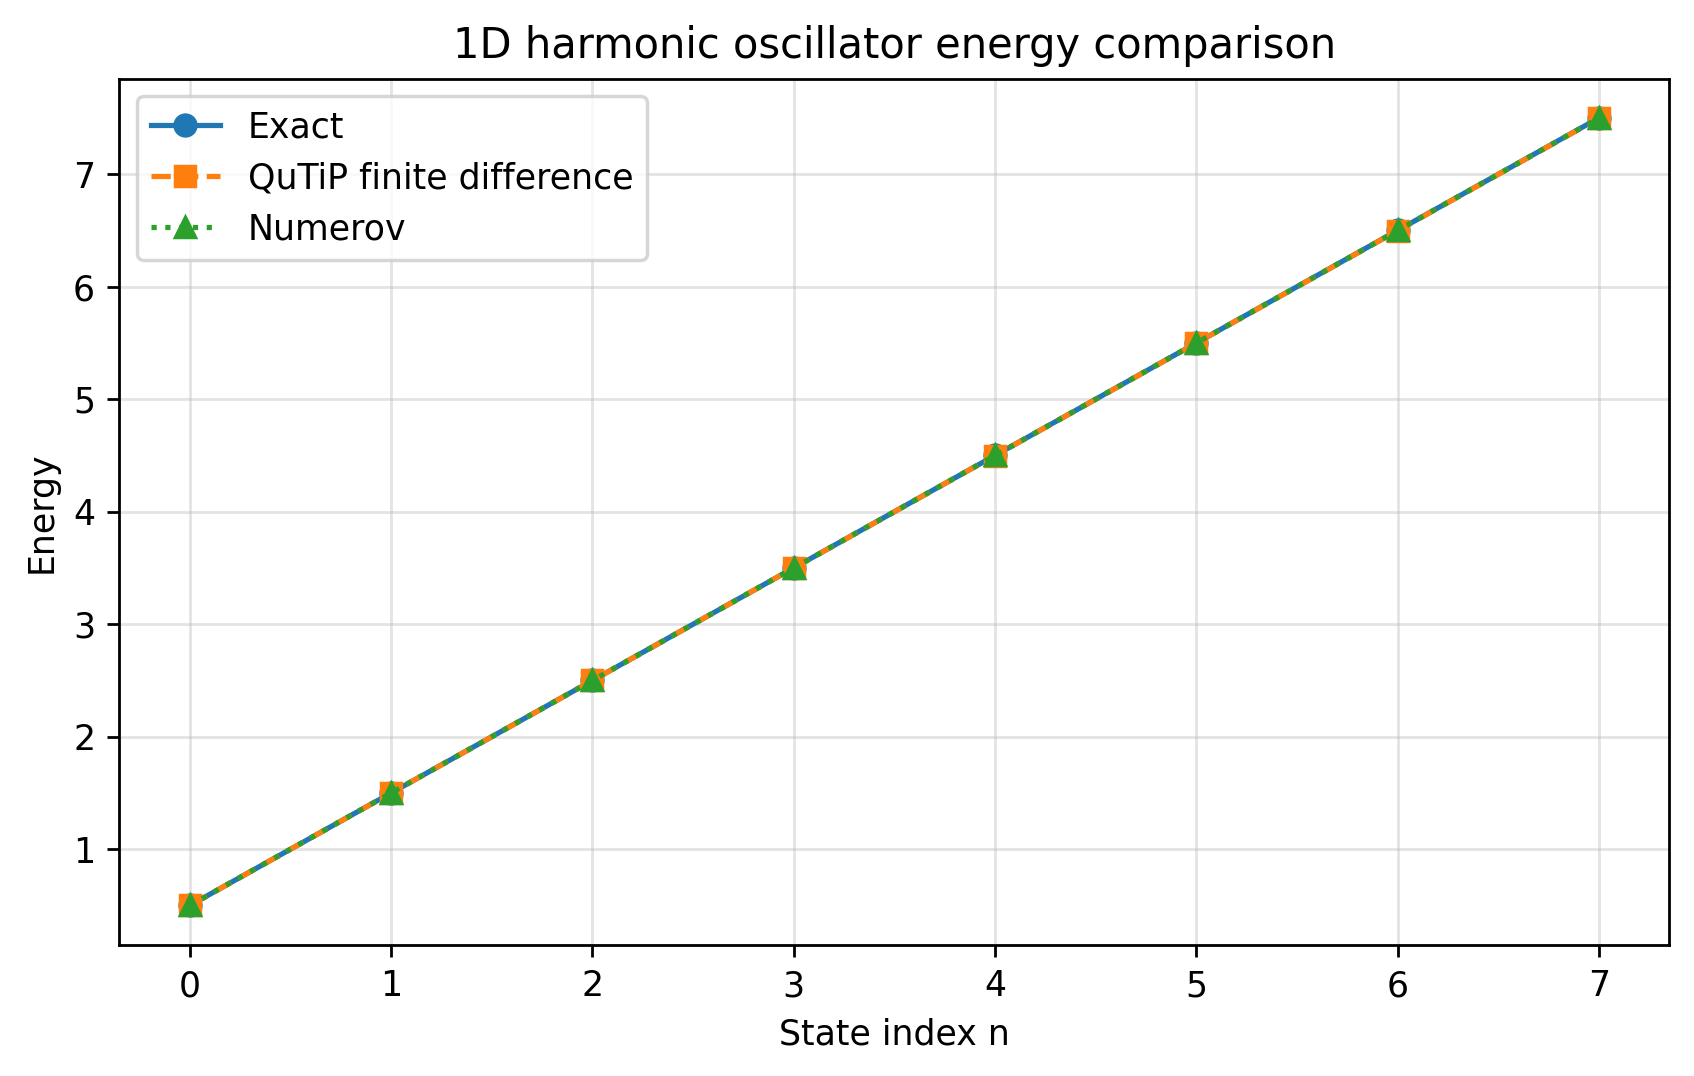

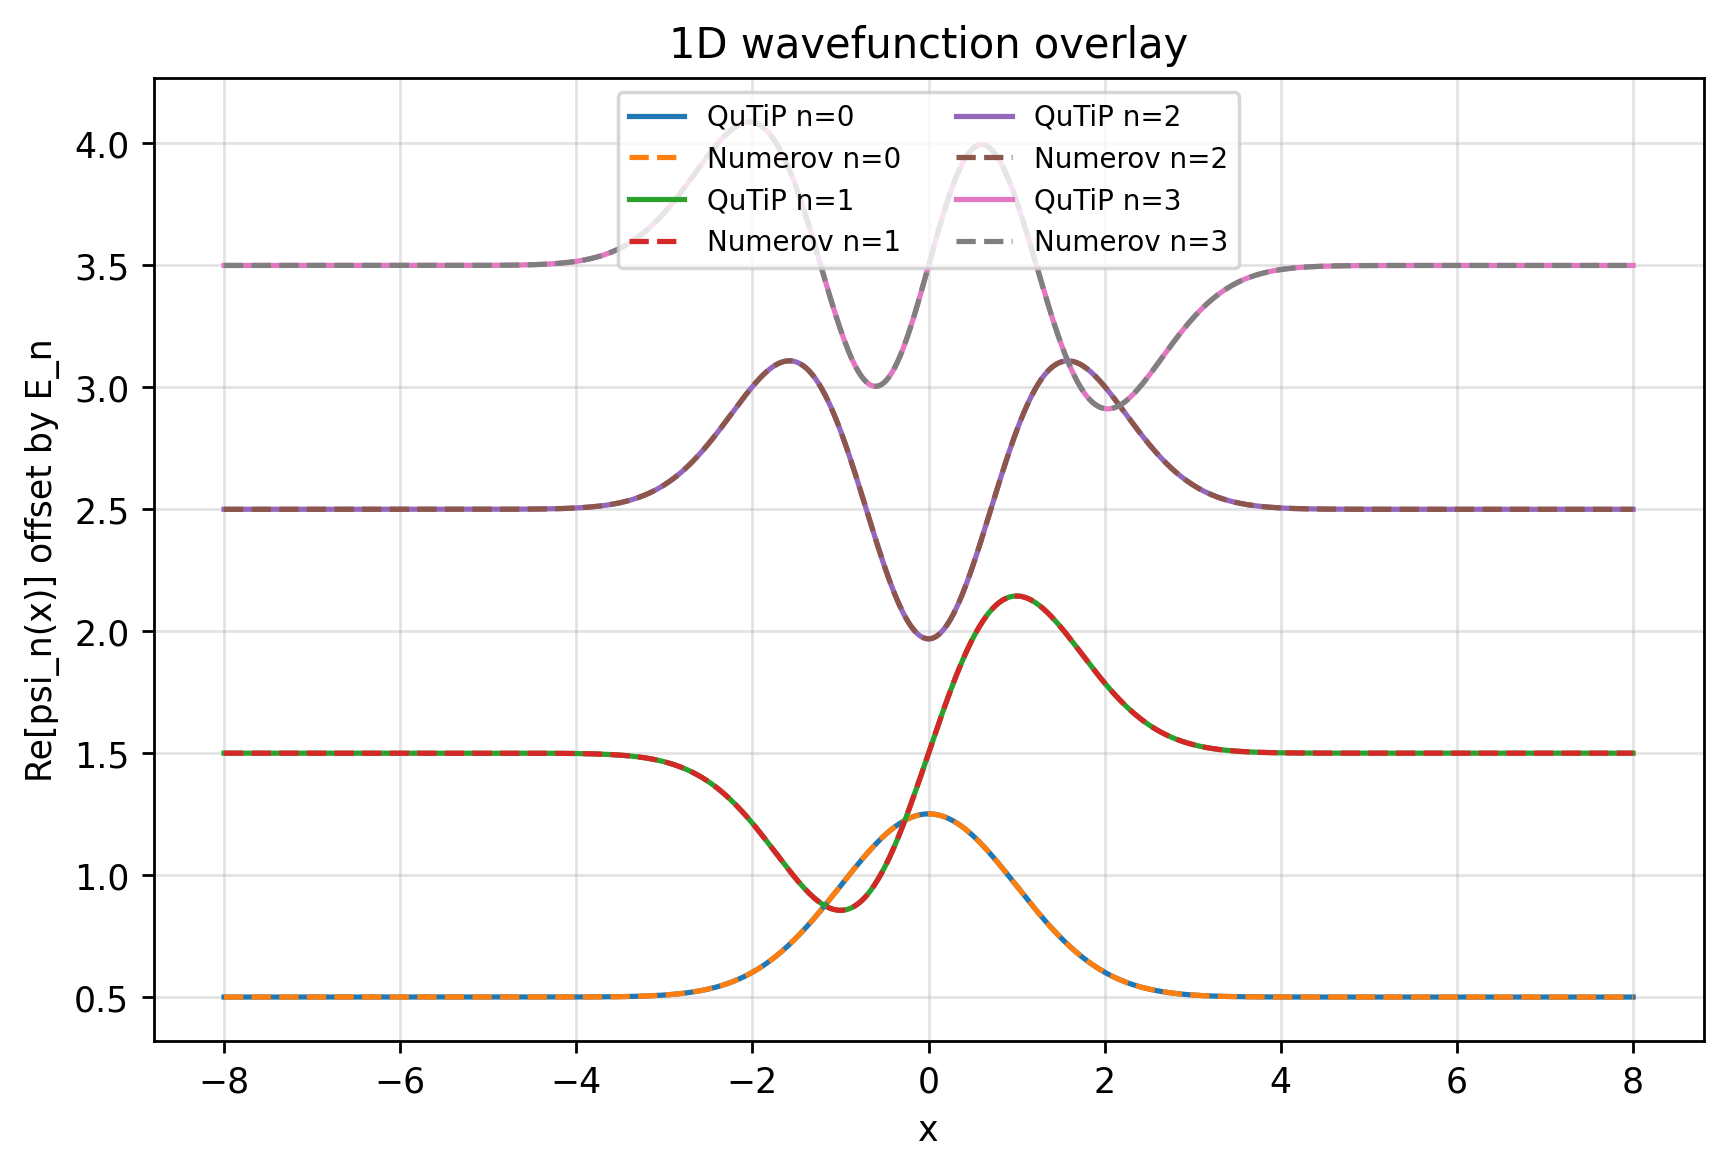

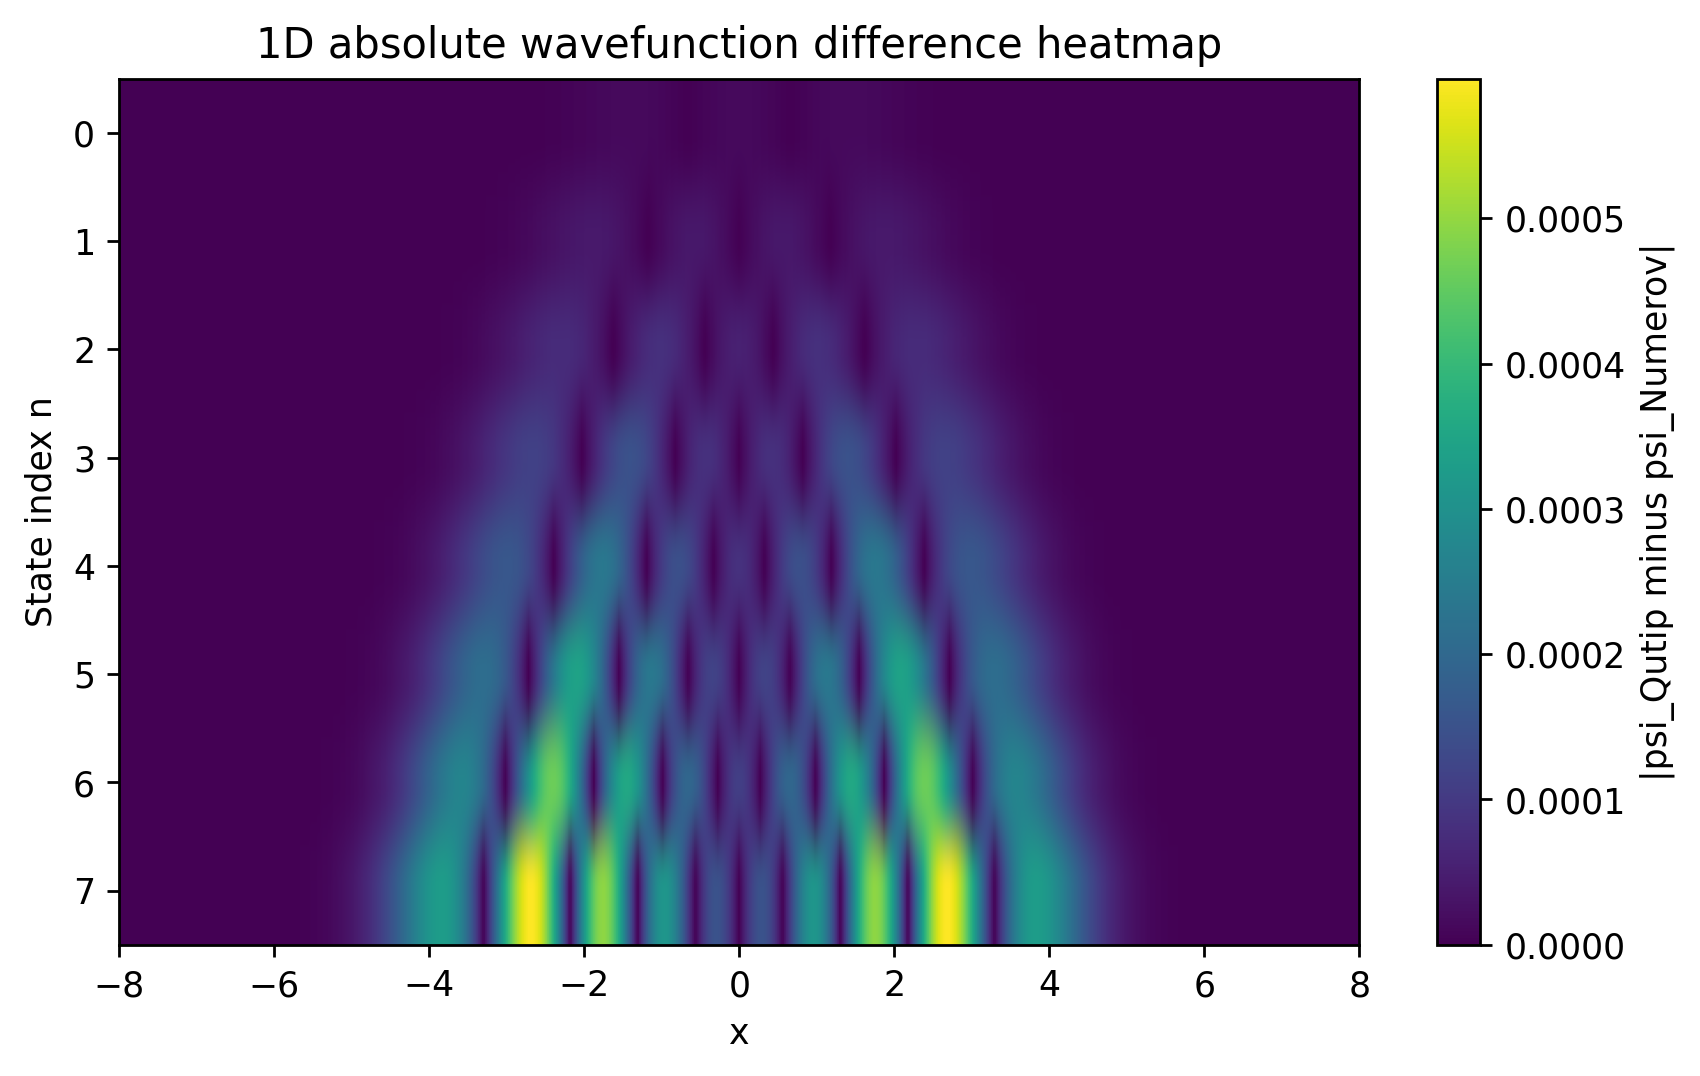

,state,"(n_x, n_y)",Exact E,QuTiP FD E,Numerov product E,QuTiP minus exact,Numerov minus exact,QuTiP minus Numerov,L2 psi difference
0,0,"(0, 0)",1.175,1.170178,1.174960,-0.004822,-0.000040,-0.004782,0.004197
1,1,"(1, 0)",2.175,2.163325,2.174889,-0.011675,-0.000111,-0.011565,0.007874
2,2,"(0, 1)",2.525,2.507658,2.524786,-0.017342,-0.000214,-0.017129,0.009926
3,3,"(2, 0)",3.175,3.149559,3.174678,-0.025441,-0.000322,-0.025119,0.014627
4,4,"(1, 1)",3.525,3.500805,3.524716,-0.024195,-0.000284,-0.023911,0.011955
5,5,"(0, 2)",3.875,3.832467,3.874264,-0.042533,-0.000736,-0.041797,0.019387
6,6,"(3, 0)",4.175,4.128806,4.174230,-0.046194,-0.000770,-0.045424,0.024499
7,7,"(2, 1)",4.525,4.487039,4.524505,-0.037961,-0.000495,-0.037466,0.017172
8,8,"(1, 2)",4.875,4.825614,4.874194,-0.049386,-0.000806,-0.048579,0.020500


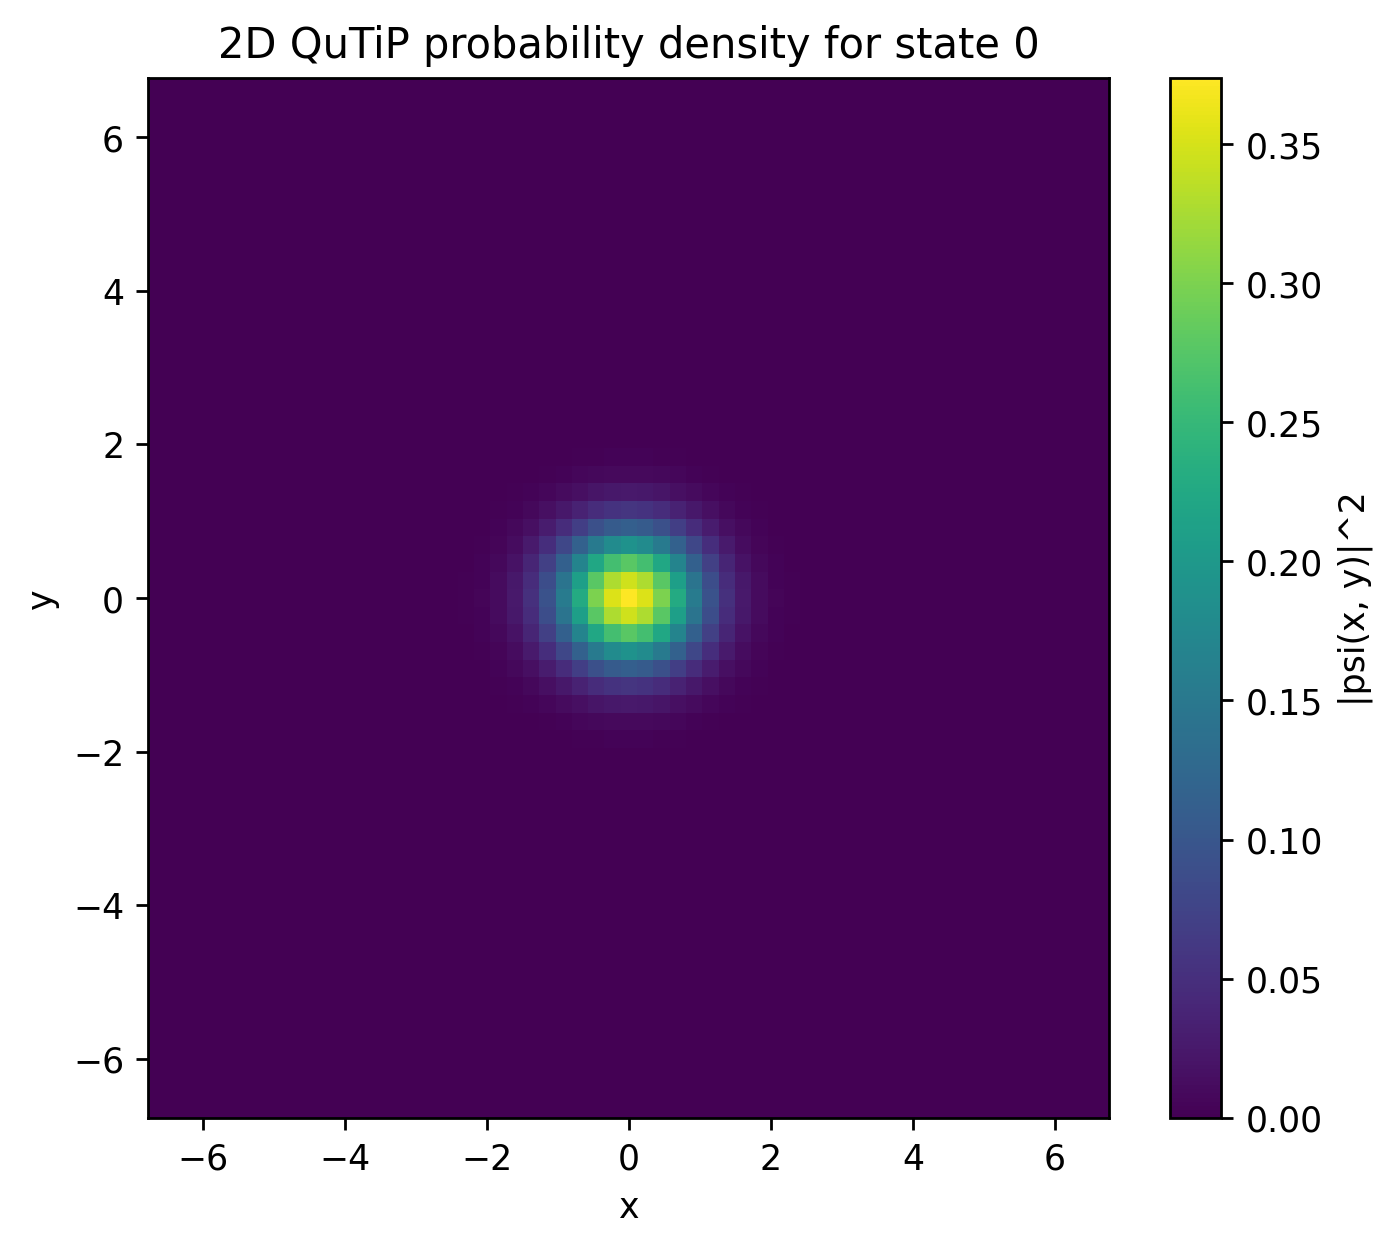

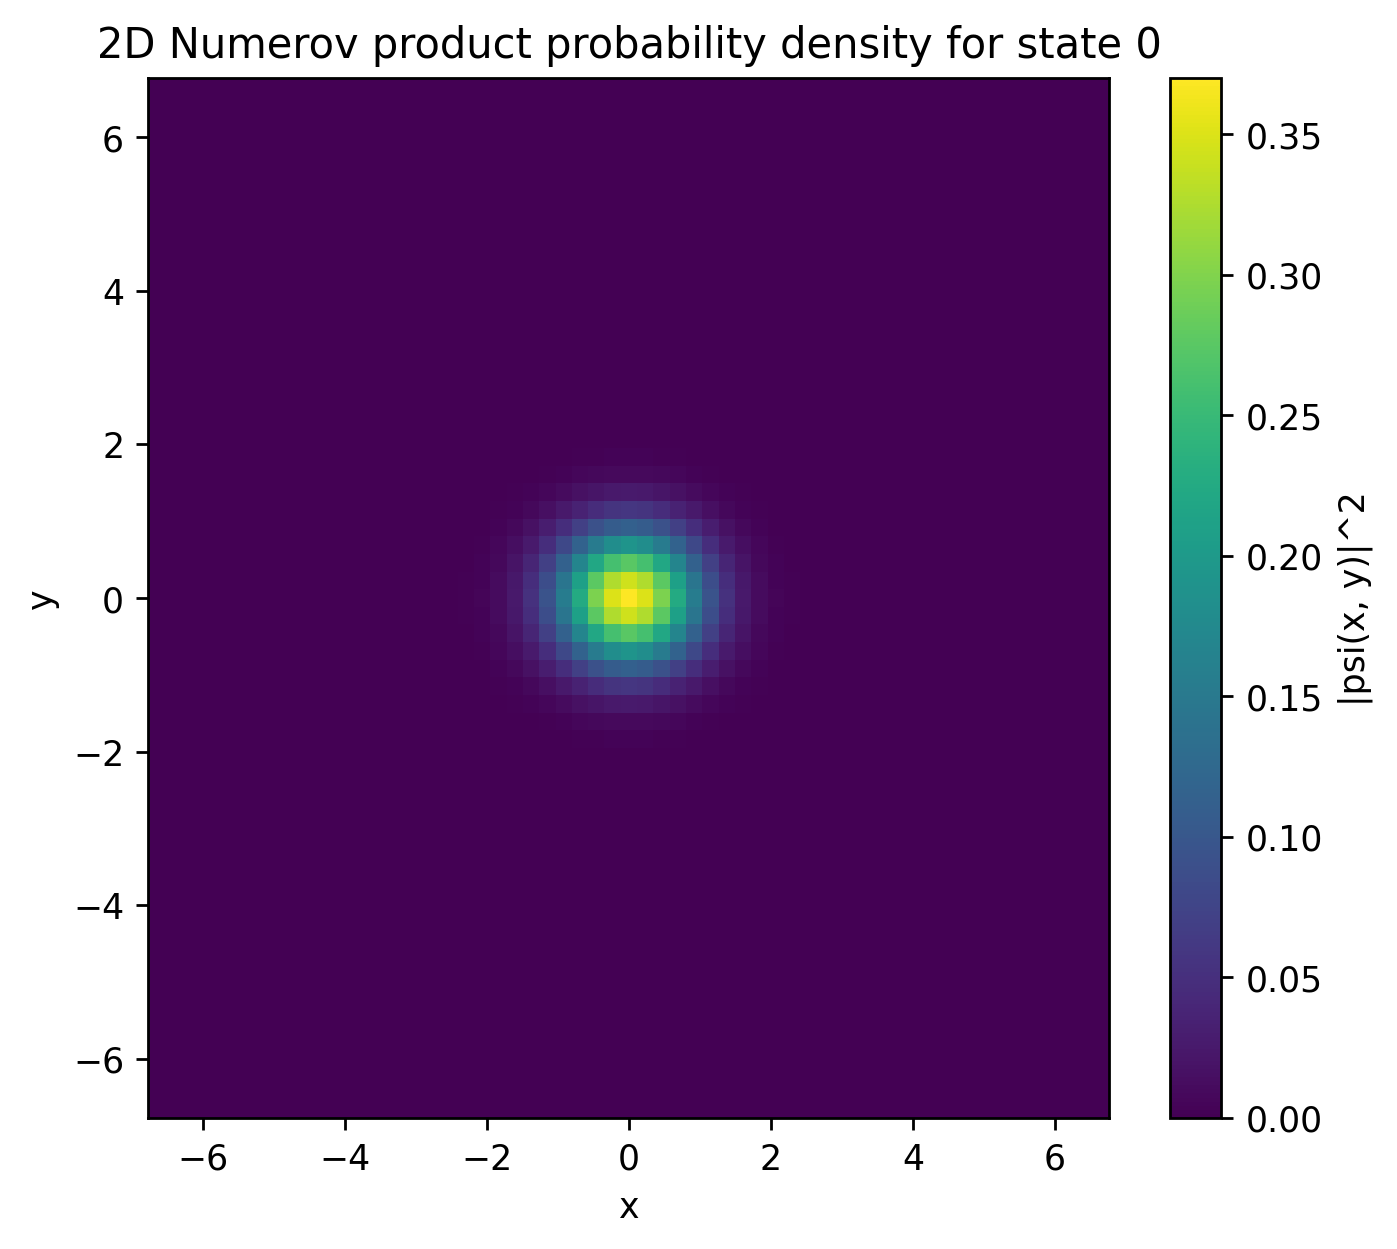

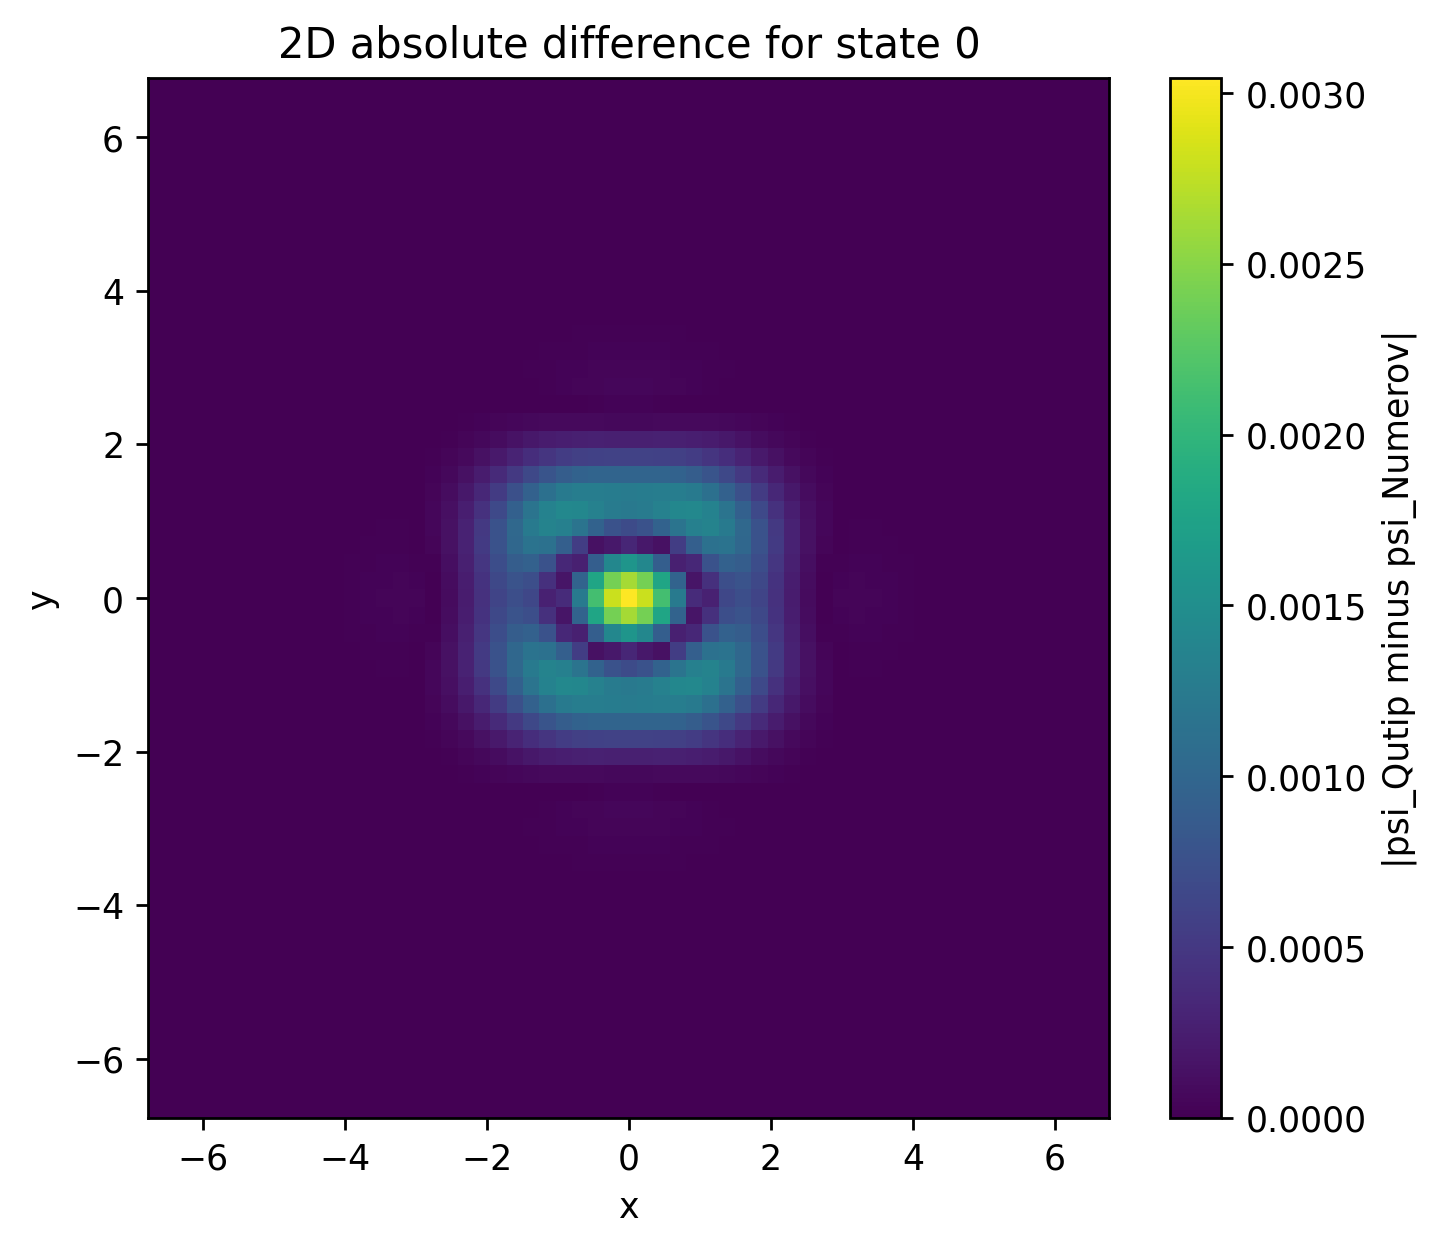

In [3]:
# @title QuTiP finite-difference vs Numerov comparison in 1D and 2D

"""Compare QuTiP finite-difference eigenstates with a Numerov eigensystem.

The comparison uses a harmonic oscillator in dimensionless units by default.
The one-dimensional section compares energies and wavefunctions directly.
The two-dimensional section uses a separable anisotropic oscillator, where the
Numerov reference is formed from products of one-dimensional Numerov states.
"""

from dataclasses import dataclass

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import qutip as qt
import scipy.linalg as la


# Control knobs
FIGURE_DPI = 250

HBAR = 1.0
MASS = 1.0

X_MIN_1D = -8.0
X_MAX_1D = 8.0
GRID_POINTS_1D = 701
OMEGA_1D = 1.0
NUM_STATES_1D = 8
PLOT_STATES_1D = 4
HEATMAP_STATES_1D = 8

RUN_2D = True
X_MIN_2D = -7.0
X_MAX_2D = 7.0
Y_MIN_2D = -7.0
Y_MAX_2D = 7.0
GRID_POINTS_2D_X = 61
GRID_POINTS_2D_Y = 61
OMEGA_X_2D = 1.0
OMEGA_Y_2D = 1.35
NUM_STATES_2D = 9
STATE_INDEX_2D_HEATMAP = 0

EIGENSOLVER_TOL = 1.0e-11
EIGENSOLVER_MAXITER = 200_000
SPARSE_EIGENSOLVER_1D = False
SPARSE_EIGENSOLVER_2D = True
NUMEROV_IMAG_TOL = 1.0e-8

mpl.rcParams["figure.dpi"] = FIGURE_DPI


@dataclass(frozen=True)
class OneDResult:
    """Container for one-dimensional stationary states."""

    x_full: np.ndarray
    x_interior: np.ndarray
    dx: float
    energies: np.ndarray
    psi_full: np.ndarray
    psi_interior: np.ndarray


@dataclass(frozen=True)
class TwoDResult:
    """Container for two-dimensional stationary states."""

    x_full: np.ndarray
    y_full: np.ndarray
    x_interior: np.ndarray
    y_interior: np.ndarray
    dx: float
    dy: float
    energies: np.ndarray
    psi_interior: np.ndarray


def display_table(dataframe: pd.DataFrame) -> None:
    """Display a table in notebooks and print it in plain Python sessions."""
    try:
        display(dataframe)
    except NameError:
        print(dataframe.to_string(index=False))


def harmonic_potential(x_grid: np.ndarray, omega: float) -> np.ndarray:
    """Return a one-dimensional harmonic oscillator potential."""
    return 0.5 * MASS * omega**2 * x_grid**2


def qutip_eigenstates(
    hamiltonian: qt.Qobj,
    num_states: int,
    use_sparse: bool,
) -> tuple[np.ndarray, list[qt.Qobj]]:
    """Call QuTiP eigenstates with compatibility across recent versions."""
    try:
        return hamiltonian.eigenstates(
            sparse=use_sparse,
            sort="low",
            eigvals=num_states,
            tol=EIGENSOLVER_TOL,
            maxiter=EIGENSOLVER_MAXITER,
        )
    except TypeError:
        return hamiltonian.eigenstates(
            sort="low",
            eigvals=num_states,
            tol=EIGENSOLVER_TOL,
            maxiter=EIGENSOLVER_MAXITER,
        )


def qutip_second_derivative(num_points: int, dx: float) -> qt.Qobj:
    """Build a second-derivative matrix with Dirichlet boundaries omitted."""
    main_diag = -2.0 * np.ones(num_points) / dx**2
    off_diag = np.ones(num_points - 1) / dx**2
    return qt.qdiags(
        [off_diag, main_diag, off_diag],
        offsets=[-1, 0, 1],
        dims=[[num_points], [num_points]],
    )


def fix_phase_1d(psi: np.ndarray) -> np.ndarray:
    """Choose a deterministic phase for a one-dimensional wavefunction."""
    adjusted = np.array(psi, dtype=np.complex128, copy=True)
    anchor = int(np.argmax(np.abs(adjusted)))
    if np.abs(adjusted[anchor]) > 0.0:
        adjusted *= np.exp(-1j * np.angle(adjusted[anchor]))
    if np.real(adjusted[anchor]) < 0.0:
        adjusted *= -1.0
    return np.real_if_close(adjusted, tol=1000)


def fix_phase_nd(psi: np.ndarray) -> np.ndarray:
    """Choose a deterministic phase for a multidimensional wavefunction."""
    adjusted = np.array(psi, dtype=np.complex128, copy=True)
    anchor = np.unravel_index(np.argmax(np.abs(adjusted)), adjusted.shape)
    if np.abs(adjusted[anchor]) > 0.0:
        adjusted *= np.exp(-1j * np.angle(adjusted[anchor]))
    if np.real(adjusted[anchor]) < 0.0:
        adjusted *= -1.0
    return np.real_if_close(adjusted, tol=1000)


def align_phase(reference: np.ndarray, target: np.ndarray, volume: float) -> np.ndarray:
    """Align the global phase of target to maximize overlap with reference."""
    aligned = np.array(target, dtype=np.complex128, copy=True)
    overlap = np.sum(np.conj(reference) * aligned) * volume
    if np.abs(overlap) > 0.0:
        aligned *= np.exp(-1j * np.angle(overlap))
    if np.real(np.sum(np.conj(reference) * aligned) * volume) < 0.0:
        aligned *= -1.0
    return np.real_if_close(aligned, tol=1000)


def normalize_columns_as_wavefunctions(
    vectors: np.ndarray,
    dx: float,
    num_states: int,
) -> np.ndarray:
    """Normalize eigenvector columns using the continuum grid measure."""
    wavefunctions = []
    for state_index in range(num_states):
        vector = np.asarray(vectors[:, state_index]).reshape(-1)
        norm = np.sqrt(np.sum(np.abs(vector) ** 2) * dx)
        wavefunction = fix_phase_1d(vector / norm)
        wavefunctions.append(wavefunction)
    return np.asarray(wavefunctions)


def solve_numerov_matrix_1d(
    x_min: float,
    x_max: float,
    grid_points: int,
    omega: float,
    num_states: int,
) -> OneDResult:
    """Solve a 1D stationary Schrödinger problem with matrix Numerov."""
    x_full = np.linspace(x_min, x_max, grid_points)
    dx = float(x_full[1] - x_full[0])
    x_interior = x_full[1:-1]
    num_interior = x_interior.size
    potential = harmonic_potential(x_interior, omega)

    main_d2 = -2.0 * np.ones(num_interior) / dx**2
    off_d2 = np.ones(num_interior - 1) / dx**2
    d2_matrix = (
        np.diag(main_d2)
        + np.diag(off_d2, k=1)
        + np.diag(off_d2, k=-1)
    )

    main_smoothing = (10.0 / 12.0) * np.ones(num_interior)
    off_smoothing = (1.0 / 12.0) * np.ones(num_interior - 1)
    smoothing_matrix = (
        np.diag(main_smoothing)
        + np.diag(off_smoothing, k=1)
        + np.diag(off_smoothing, k=-1)
    )

    lhs_matrix = (
        -(HBAR**2 / (2.0 * MASS)) * d2_matrix
        + smoothing_matrix @ np.diag(potential)
    )
    rhs_matrix = smoothing_matrix

    raw_energies, raw_vectors = la.eig(lhs_matrix, rhs_matrix)
    accepted = np.abs(np.imag(raw_energies)) < NUMEROV_IMAG_TOL
    energies = np.real(raw_energies[accepted])
    vectors = raw_vectors[:, accepted]

    order = np.argsort(energies)
    energies = energies[order][:num_states]
    vectors = vectors[:, order][:, :num_states]

    psi_interior = normalize_columns_as_wavefunctions(vectors, dx, num_states)
    psi_full = np.zeros((num_states, grid_points), dtype=psi_interior.dtype)
    psi_full[:, 1:-1] = psi_interior

    return OneDResult(
        x_full=x_full,
        x_interior=x_interior,
        dx=dx,
        energies=energies,
        psi_full=psi_full,
        psi_interior=psi_interior,
    )


def solve_qutip_finite_difference_1d(
    x_min: float,
    x_max: float,
    grid_points: int,
    omega: float,
    num_states: int,
) -> OneDResult:
    """Solve a 1D stationary Schrödinger problem with QuTiP diagonalization."""
    x_full = np.linspace(x_min, x_max, grid_points)
    dx = float(x_full[1] - x_full[0])
    x_interior = x_full[1:-1]
    num_interior = x_interior.size

    d2_operator = qutip_second_derivative(num_interior, dx)
    kinetic = -(HBAR**2 / (2.0 * MASS)) * d2_operator
    potential = qt.qdiags(
        harmonic_potential(x_interior, omega),
        offsets=0,
        dims=[[num_interior], [num_interior]],
    )
    hamiltonian = kinetic + potential

    energies, states = qutip_eigenstates(
        hamiltonian,
        num_states,
        SPARSE_EIGENSOLVER_1D,
    )

    psi_interior = []
    for state in states[:num_states]:
        vector = np.asarray(state.full()).reshape(-1) / np.sqrt(dx)
        psi_interior.append(fix_phase_1d(vector))
    psi_interior = np.asarray(psi_interior)

    psi_full = np.zeros((num_states, grid_points), dtype=psi_interior.dtype)
    psi_full[:, 1:-1] = psi_interior

    return OneDResult(
        x_full=x_full,
        x_interior=x_interior,
        dx=dx,
        energies=np.asarray(energies[:num_states], dtype=float),
        psi_full=psi_full,
        psi_interior=psi_interior,
    )


def exact_1d_harmonic_energies(omega: float, num_states: int) -> np.ndarray:
    """Return exact one-dimensional harmonic oscillator energies."""
    indices = np.arange(num_states)
    return HBAR * omega * (indices + 0.5)


def make_1d_comparison_table(
    qutip_result: OneDResult,
    numerov_result: OneDResult,
    omega: float,
) -> pd.DataFrame:
    """Create a table comparing energies and wavefunction errors."""
    exact = exact_1d_harmonic_energies(omega, qutip_result.energies.size)
    l2_errors = []
    for state_index in range(qutip_result.energies.size):
        aligned = align_phase(
            qutip_result.psi_interior[state_index],
            numerov_result.psi_interior[state_index],
            qutip_result.dx,
        )
        error = np.sqrt(
            np.sum(np.abs(qutip_result.psi_interior[state_index] - aligned) ** 2)
            * qutip_result.dx
        )
        l2_errors.append(error)

    return pd.DataFrame(
        {
            "n": np.arange(qutip_result.energies.size),
            "Exact E_n": exact,
            "QuTiP FD E_n": qutip_result.energies,
            "Numerov E_n": numerov_result.energies,
            "QuTiP minus exact": qutip_result.energies - exact,
            "Numerov minus exact": numerov_result.energies - exact,
            "QuTiP minus Numerov": qutip_result.energies - numerov_result.energies,
            "L2 psi difference": l2_errors,
        }
    )


def plot_1d_energy_comparison(comparison: pd.DataFrame) -> None:
    """Render the one-dimensional energy comparison."""
    fig, ax = plt.subplots(figsize=(8.0, 4.5))
    ax.plot(comparison["n"], comparison["Exact E_n"], marker="o", label="Exact")
    ax.plot(
        comparison["n"],
        comparison["QuTiP FD E_n"],
        marker="s",
        linestyle="--",
        label="QuTiP finite difference",
    )
    ax.plot(
        comparison["n"],
        comparison["Numerov E_n"],
        marker="^",
        linestyle=":",
        label="Numerov",
    )
    ax.set_xlabel("State index n")
    ax.set_ylabel("Energy")
    ax.set_title("1D harmonic oscillator energy comparison")
    ax.grid(True, alpha=0.35)
    ax.legend()
    plt.show()


def plot_1d_wavefunctions(
    qutip_result: OneDResult,
    numerov_result: OneDResult,
    num_states: int,
) -> None:
    """Render offset wavefunction comparisons for the lowest states."""
    fig, ax = plt.subplots(figsize=(8.0, 5.0))
    count = min(num_states, qutip_result.energies.size)
    for state_index in range(count):
        aligned = align_phase(
            qutip_result.psi_interior[state_index],
            numerov_result.psi_interior[state_index],
            qutip_result.dx,
        )
        qutip_full = np.zeros_like(qutip_result.x_full, dtype=np.complex128)
        numerov_full = np.zeros_like(qutip_result.x_full, dtype=np.complex128)
        qutip_full[1:-1] = qutip_result.psi_interior[state_index]
        numerov_full[1:-1] = aligned
        offset = qutip_result.energies[state_index]
        ax.plot(
            qutip_result.x_full,
            np.real(qutip_full) + offset,
            label=f"QuTiP n={state_index}",
        )
        ax.plot(
            qutip_result.x_full,
            np.real(numerov_full) + offset,
            linestyle="--",
            label=f"Numerov n={state_index}",
        )
    ax.set_xlabel("x")
    ax.set_ylabel("Re[psi_n(x)] offset by E_n")
    ax.set_title("1D wavefunction overlay")
    ax.grid(True, alpha=0.35)
    ax.legend(ncol=2, fontsize=8)
    plt.show()


def plot_1d_error_heatmap(
    qutip_result: OneDResult,
    numerov_result: OneDResult,
    num_states: int,
) -> None:
    """Render a heatmap of absolute wavefunction differences."""
    count = min(num_states, qutip_result.energies.size)
    error_rows = []
    for state_index in range(count):
        aligned = align_phase(
            qutip_result.psi_interior[state_index],
            numerov_result.psi_interior[state_index],
            qutip_result.dx,
        )
        error_row = np.zeros_like(qutip_result.x_full, dtype=float)
        error_row[1:-1] = np.abs(qutip_result.psi_interior[state_index] - aligned)
        error_rows.append(error_row)

    error_map = np.asarray(error_rows)
    fig, ax = plt.subplots(figsize=(8.0, 4.5))
    image = ax.imshow(
        error_map,
        aspect="auto",
        extent=[
            qutip_result.x_full[0],
            qutip_result.x_full[-1],
            count - 0.5,
            -0.5,
        ],
    )
    ax.set_xlabel("x")
    ax.set_ylabel("State index n")
    ax.set_title("1D absolute wavefunction difference heatmap")
    fig.colorbar(image, ax=ax, label="|psi_Qutip minus psi_Numerov|")
    plt.show()


def solve_qutip_finite_difference_2d(
    x_min: float,
    x_max: float,
    y_min: float,
    y_max: float,
    grid_points_x: int,
    grid_points_y: int,
    omega_x: float,
    omega_y: float,
    num_states: int,
) -> TwoDResult:
    """Solve a separable 2D oscillator using a QuTiP tensor-grid Hamiltonian."""
    x_full = np.linspace(x_min, x_max, grid_points_x)
    y_full = np.linspace(y_min, y_max, grid_points_y)
    dx = float(x_full[1] - x_full[0])
    dy = float(y_full[1] - y_full[0])
    x_interior = x_full[1:-1]
    y_interior = y_full[1:-1]
    nx = x_interior.size
    ny = y_interior.size

    d2_x = qutip_second_derivative(nx, dx)
    d2_y = qutip_second_derivative(ny, dy)
    identity_x = qt.qeye(nx)
    identity_y = qt.qeye(ny)

    kinetic_x = -(HBAR**2 / (2.0 * MASS)) * qt.tensor(d2_x, identity_y)
    kinetic_y = -(HBAR**2 / (2.0 * MASS)) * qt.tensor(identity_x, d2_y)

    potential_2d = (
        harmonic_potential(x_interior, omega_x)[:, None]
        + harmonic_potential(y_interior, omega_y)[None, :]
    )
    potential_operator = qt.qdiags(
        potential_2d.ravel(order="C"),
        offsets=0,
        dims=[[nx, ny], [nx, ny]],
    )

    hamiltonian = kinetic_x + kinetic_y + potential_operator
    energies, states = qutip_eigenstates(
        hamiltonian,
        num_states,
        SPARSE_EIGENSOLVER_2D,
    )

    psi_interior = []
    for state in states[:num_states]:
        vector = np.asarray(state.full()).reshape(-1)
        grid = vector.reshape((nx, ny), order="C") / np.sqrt(dx * dy)
        psi_interior.append(fix_phase_nd(grid))
    psi_interior = np.asarray(psi_interior)

    return TwoDResult(
        x_full=x_full,
        y_full=y_full,
        x_interior=x_interior,
        y_interior=y_interior,
        dx=dx,
        dy=dy,
        energies=np.asarray(energies[:num_states], dtype=float),
        psi_interior=psi_interior,
    )


def generate_numerov_products_2d(
    x_result: OneDResult,
    y_result: OneDResult,
    num_states: int,
) -> tuple[np.ndarray, list[tuple[int, int]], np.ndarray]:
    """Generate product states from 1D Numerov eigenstates."""
    candidates = []
    states_per_axis = min(num_states, x_result.energies.size, y_result.energies.size)
    for nx_index in range(states_per_axis):
        for ny_index in range(states_per_axis):
            energy = x_result.energies[nx_index] + y_result.energies[ny_index]
            wavefunction = np.outer(
                x_result.psi_interior[nx_index],
                y_result.psi_interior[ny_index],
            )
            candidates.append((energy, nx_index, ny_index, wavefunction))

    candidates.sort(key=lambda item: item[0])
    selected = candidates[:num_states]
    energies = np.asarray([item[0] for item in selected])
    labels = [(item[1], item[2]) for item in selected]
    wavefunctions = np.asarray([item[3] for item in selected])
    return energies, labels, wavefunctions


def exact_2d_harmonic_energy(
    nx_index: int,
    ny_index: int,
    omega_x: float,
    omega_y: float,
) -> float:
    """Return the exact separable 2D harmonic oscillator energy."""
    return HBAR * omega_x * (nx_index + 0.5) + HBAR * omega_y * (ny_index + 0.5)


def make_2d_comparison_table(
    qutip_result: TwoDResult,
    numerov_energies: np.ndarray,
    numerov_labels: list[tuple[int, int]],
    numerov_wavefunctions: np.ndarray,
    omega_x: float,
    omega_y: float,
) -> pd.DataFrame:
    """Create a table comparing separable two-dimensional states."""
    rows = []
    volume = qutip_result.dx * qutip_result.dy
    for state_index, (nx_index, ny_index) in enumerate(numerov_labels):
        exact_energy = exact_2d_harmonic_energy(
            nx_index,
            ny_index,
            omega_x,
            omega_y,
        )
        aligned = align_phase(
            qutip_result.psi_interior[state_index],
            numerov_wavefunctions[state_index],
            volume,
        )
        l2_error = np.sqrt(
            np.sum(np.abs(qutip_result.psi_interior[state_index] - aligned) ** 2)
            * volume
        )
        rows.append(
            {
                "state": state_index,
                "(n_x, n_y)": f"({nx_index}, {ny_index})",
                "Exact E": exact_energy,
                "QuTiP FD E": qutip_result.energies[state_index],
                "Numerov product E": numerov_energies[state_index],
                "QuTiP minus exact": (
                    qutip_result.energies[state_index] - exact_energy
                ),
                "Numerov minus exact": numerov_energies[state_index] - exact_energy,
                "QuTiP minus Numerov": (
                    qutip_result.energies[state_index]
                    - numerov_energies[state_index]
                ),
                "L2 psi difference": l2_error,
            }
        )
    return pd.DataFrame(rows)


def plot_2d_density_heatmap(
    result: TwoDResult,
    state_index: int,
    title: str,
) -> None:
    """Render a two-dimensional probability density heatmap."""
    state_index = min(state_index, result.psi_interior.shape[0] - 1)
    density = np.abs(result.psi_interior[state_index]) ** 2
    fig, ax = plt.subplots(figsize=(6.2, 5.4))
    image = ax.imshow(
        density.T,
        origin="lower",
        extent=[
            result.x_interior[0],
            result.x_interior[-1],
            result.y_interior[0],
            result.y_interior[-1],
        ],
        aspect="auto",
    )
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label="|psi(x, y)|^2")
    plt.show()


def plot_2d_numerov_density_heatmap(
    qutip_result: TwoDResult,
    numerov_wavefunctions: np.ndarray,
    state_index: int,
    title: str,
) -> None:
    """Render a two-dimensional Numerov product density heatmap."""
    state_index = min(state_index, numerov_wavefunctions.shape[0] - 1)
    density = np.abs(numerov_wavefunctions[state_index]) ** 2
    fig, ax = plt.subplots(figsize=(6.2, 5.4))
    image = ax.imshow(
        density.T,
        origin="lower",
        extent=[
            qutip_result.x_interior[0],
            qutip_result.x_interior[-1],
            qutip_result.y_interior[0],
            qutip_result.y_interior[-1],
        ],
        aspect="auto",
    )
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label="|psi(x, y)|^2")
    plt.show()


def plot_2d_difference_heatmap(
    qutip_result: TwoDResult,
    numerov_wavefunctions: np.ndarray,
    state_index: int,
) -> None:
    """Render a two-dimensional absolute difference heatmap."""
    state_index = min(state_index, numerov_wavefunctions.shape[0] - 1)
    aligned = align_phase(
        qutip_result.psi_interior[state_index],
        numerov_wavefunctions[state_index],
        qutip_result.dx * qutip_result.dy,
    )
    difference = np.abs(qutip_result.psi_interior[state_index] - aligned)
    fig, ax = plt.subplots(figsize=(6.2, 5.4))
    image = ax.imshow(
        difference.T,
        origin="lower",
        extent=[
            qutip_result.x_interior[0],
            qutip_result.x_interior[-1],
            qutip_result.y_interior[0],
            qutip_result.y_interior[-1],
        ],
        aspect="auto",
    )
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"2D absolute difference for state {state_index}")
    fig.colorbar(image, ax=ax, label="|psi_Qutip minus psi_Numerov|")
    plt.show()


qutip_1d = solve_qutip_finite_difference_1d(
    X_MIN_1D,
    X_MAX_1D,
    GRID_POINTS_1D,
    OMEGA_1D,
    NUM_STATES_1D,
)
numerov_1d = solve_numerov_matrix_1d(
    X_MIN_1D,
    X_MAX_1D,
    GRID_POINTS_1D,
    OMEGA_1D,
    NUM_STATES_1D,
)

comparison_1d = make_1d_comparison_table(qutip_1d, numerov_1d, OMEGA_1D)
display_table(comparison_1d)

plot_1d_energy_comparison(comparison_1d)
plot_1d_wavefunctions(qutip_1d, numerov_1d, PLOT_STATES_1D)
plot_1d_error_heatmap(qutip_1d, numerov_1d, HEATMAP_STATES_1D)

if RUN_2D:
    qutip_2d = solve_qutip_finite_difference_2d(
        X_MIN_2D,
        X_MAX_2D,
        Y_MIN_2D,
        Y_MAX_2D,
        GRID_POINTS_2D_X,
        GRID_POINTS_2D_Y,
        OMEGA_X_2D,
        OMEGA_Y_2D,
        NUM_STATES_2D,
    )

    numerov_x_2d = solve_numerov_matrix_1d(
        X_MIN_2D,
        X_MAX_2D,
        GRID_POINTS_2D_X,
        OMEGA_X_2D,
        NUM_STATES_2D,
    )
    numerov_y_2d = solve_numerov_matrix_1d(
        Y_MIN_2D,
        Y_MAX_2D,
        GRID_POINTS_2D_Y,
        OMEGA_Y_2D,
        NUM_STATES_2D,
    )
    numerov_2d_energies, numerov_2d_labels, numerov_2d_wavefunctions = (
        generate_numerov_products_2d(
            numerov_x_2d,
            numerov_y_2d,
            NUM_STATES_2D,
        )
    )

    comparison_2d = make_2d_comparison_table(
        qutip_2d,
        numerov_2d_energies,
        numerov_2d_labels,
        numerov_2d_wavefunctions,
        OMEGA_X_2D,
        OMEGA_Y_2D,
    )
    display_table(comparison_2d)

    plot_2d_density_heatmap(
        qutip_2d,
        STATE_INDEX_2D_HEATMAP,
        f"2D QuTiP probability density for state {STATE_INDEX_2D_HEATMAP}",
    )
    plot_2d_numerov_density_heatmap(
        qutip_2d,
        numerov_2d_wavefunctions,
        STATE_INDEX_2D_HEATMAP,
        f"2D Numerov product probability density for state {STATE_INDEX_2D_HEATMAP}",
    )
    plot_2d_difference_heatmap(
        qutip_2d,
        numerov_2d_wavefunctions,
        STATE_INDEX_2D_HEATMAP,
    )